# 06 — Advanced Model: R3D-18 (3D CNN)
### Dataset: FaceForensics++ (C23) | Cross-Dataset: Celeb-DF v2
This notebook covers:
- R3D-18 as a 3D CNN deepfake detector for temporal anomaly detection
- Processes the full (T, H, W) video clip via 3D convolutions
- Two-stage training: frozen backbone → full fine-tuning
- Evaluation on FF++ test set with confusion matrix and ROC curve
- Zero-shot cross-dataset evaluation on Celeb-DF v2
- Generalization gap analysis
- Model and results saved to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import gc
import copy
import time
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

print("All libraries imported successfully.")
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

Mounted at /content/drive
All libraries imported successfully.
PyTorch version : 2.10.0+cu128
CUDA available  : True


In [ ]:
# Reload project paths and constants to make this notebook fully self-contained
PROJECT_ROOT = Path("/content/drive/MyDrive/deepfake_binary_project")

PROC_ROOT  = PROJECT_ROOT / "processed"
INDEX_DIR  = PROJECT_ROOT / "index"
MODEL_DIR  = PROJECT_ROOT / "models"
PLOTS_DIR  = PROJECT_ROOT / "eda_plots"

FFPP_FACES_ROOT    = PROC_ROOT / "ffpp_face_crops_224"
CELEBDF_FACES_ROOT = PROC_ROOT / "celebdf_face_crops_224"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

SEED        = 42
NUM_FRAMES  = 16
IMG_SIZE    = 224
BATCH_SIZE  = 8
NUM_WORKERS = 2
ACCUM_STEPS = 4

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)

print(f"Device              : {device} ({torch.cuda.get_device_name(0)})")
print(f"Frames/video        : {NUM_FRAMES}")
print(f"Image size          : {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size          : {BATCH_SIZE}")
print(f"Gradient accum steps: {ACCUM_STEPS}")
print(f"Effective batch size: {BATCH_SIZE * ACCUM_STEPS}")

Device              : cuda (Tesla T4)
Frames/video        : 16
Image size          : 224x224
Batch size          : 8
Gradient accum steps: 4
Effective batch size: 32


In [ ]:
# Load pre-built split index files generated in notebook 01
train_df   = pd.read_csv(INDEX_DIR / "ffpp_train.csv")
val_df     = pd.read_csv(INDEX_DIR / "ffpp_val.csv")
test_df    = pd.read_csv(INDEX_DIR / "ffpp_test.csv")
df_celebdf = pd.read_csv(INDEX_DIR / "celebdf_test.csv")

print("Index files loaded successfully.")
print(f"\nFF++ Train : {len(train_df)} videos  (real: {(train_df.binary_target==0).sum()} | fake: {(train_df.binary_target==1).sum()})")
print(f"FF++ Val   : {len(val_df)} videos  (real: {(val_df.binary_target==0).sum()} | fake: {(val_df.binary_target==1).sum()})")
print(f"FF++ Test  : {len(test_df)} videos  (real: {(test_df.binary_target==0).sum()} | fake: {(test_df.binary_target==1).sum()})")
print(f"\nCeleb-DF v2: {len(df_celebdf)} videos  (real: {(df_celebdf.binary_target==0).sum()} | fake: {(df_celebdf.binary_target==1).sum()})")

Index files loaded successfully.

FF++ Train : 4200 videos  (real: 700 | fake: 3500)
FF++ Val   : 900 videos  (real: 150 | fake: 750)
FF++ Test  : 900 videos  (real: 150 | fake: 750)

Celeb-DF v2: 6529 videos  (real: 890 | fake: 5639)


In [ ]:
train_transform = T.Compose([
    T.ToPILImage(),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    T.RandomRotation(degrees=10),
    T.RandomGrayscale(p=0.02),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5))], p=0.3),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = T.Compose([
    T.ToPILImage(),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class DeepfakeDataset(Dataset):
    """
    Loads pre-extracted MTCNN face crops and applies the specified transform.
    Returns a tensor of shape (T, C, H, W) and a binary label.
    """
    def __init__(self, df, faces_root, transform=None, num_frames=NUM_FRAMES):
        self.df         = df.reset_index(drop=True)
        self.faces_root = Path(faces_root)
        self.transform  = transform
        self.num_frames = num_frames

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row       = self.df.iloc[idx]
        vid_stem  = Path(row["path"]).stem
        label     = int(row["binary_target"])
        frame_dir = self.faces_root / row["binary_label"] / vid_stem

        frames = []
        for i in range(self.num_frames):
            img = cv2.imread(str(frame_dir / f"frame_{i:02d}.jpg"))
            if img is None:
                img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            if self.transform:
                img = self.transform(img)
            else:
                img = T.Compose([T.ToPILImage(), T.ToTensor()])(img)
            frames.append(img)

        return torch.stack(frames), torch.tensor(label, dtype=torch.long)

# WeightedRandomSampler to handle 1:5 class imbalance
targets = train_df["binary_target"].values
counts  = np.bincount(targets)
weights = 1.0 / counts[targets]
sampler = WeightedRandomSampler(
    weights     = torch.tensor(weights, dtype=torch.float),
    num_samples = len(weights),
    replacement = True
)

train_dataset   = DeepfakeDataset(train_df,   FFPP_FACES_ROOT,    transform=train_transform)
val_dataset     = DeepfakeDataset(val_df,     FFPP_FACES_ROOT,    transform=val_transform)
test_dataset    = DeepfakeDataset(test_df,    FFPP_FACES_ROOT,    transform=val_transform)
celebdf_dataset = DeepfakeDataset(df_celebdf, CELEBDF_FACES_ROOT, transform=val_transform)

train_loader   = DataLoader(train_dataset,   batch_size=BATCH_SIZE, sampler=sampler,
                            num_workers=NUM_WORKERS, pin_memory=True)
val_loader     = DataLoader(val_dataset,     batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
test_loader    = DataLoader(test_dataset,    batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
celebdf_loader = DataLoader(celebdf_dataset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train dataset    : {len(train_dataset)} videos  | {len(train_loader)} batches")
print(f"Val dataset      : {len(val_dataset)} videos  | {len(val_loader)} batches")
print(f"Test dataset     : {len(test_dataset)} videos  | {len(test_loader)} batches")
print(f"Celeb-DF dataset : {len(celebdf_dataset)} videos | {len(celebdf_loader)} batches")

Train dataset    : 4200 videos  | 525 batches
Val dataset      : 900 videos  | 113 batches
Test dataset     : 900 videos  | 113 batches
Celeb-DF dataset : 6529 videos | 817 batches


In [ ]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, criterion, optimizer, device, accum_steps=ACCUM_STEPS):
    model.train()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    optimizer.zero_grad()

    for step, (frames, labels) in enumerate(loader):
        frames = frames.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(frames)
        loss    = criterion(outputs, labels) / accum_steps
        loss.backward()

        if (step + 1) % accum_steps == 0 or (step + 1) == len(loader):
            optimizer.step()
            optimizer.zero_grad()

        running_loss += loss.item() * accum_steps * labels.size(0)
        probs = torch.softmax(outputs.detach(), dim=1)[:, 1]
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(outputs.detach().argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return {
        "loss"     : running_loss / len(loader.dataset),
        "acc"      : accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall"   : recall_score(all_labels, all_preds, zero_division=0),
        "f1"       : f1_score(all_labels, all_preds, zero_division=0),
        "auc"      : roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0,
    }


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for frames, labels in loader:
            frames = frames.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(frames)
            loss    = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return {
        "loss"     : running_loss / len(loader.dataset),
        "acc"      : accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall"   : recall_score(all_labels, all_preds, zero_division=0),
        "f1"       : f1_score(all_labels, all_preds, zero_division=0),
        "auc"      : roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0,
        "y_true"   : all_labels,
        "y_pred"   : all_preds,
        "y_prob"   : all_probs,
    }


def save_results(results, path):
    """Serialize evaluation results to JSON, converting numpy types."""
    def convert(obj):
        if isinstance(obj, (np.integer)): return int(obj)
        if isinstance(obj, (np.floating)): return float(obj)
        if isinstance(obj, list): return [convert(i) for i in obj]
        return obj
    with open(path, "w") as f:
        json.dump({k: convert(v) for k, v in results.items()}, f, indent=2)


def print_epoch(epoch, total, tr, val, lr, t):
    print(f"Epoch [{epoch}/{total}]")
    print(f"  Train  loss={tr['loss']:.4f}  acc={tr['acc']:.4f}  f1={tr['f1']:.4f}  auc={tr['auc']:.4f}")
    print(f"  Val    loss={val['loss']:.4f}  acc={val['acc']:.4f}  f1={val['f1']:.4f}  auc={val['auc']:.4f}")
    print(f"  LR={lr:.6f}  time={t/60:.2f} min")
    print("-" * 65)


print("Shared training utilities defined.")

Shared training utilities defined.


## Part 1 — R3D-18 Model Definition
R3D-18 is a 3D convolutional network that processes the full video clip as a
(B, C, T, H, W) tensor, enabling explicit temporal feature extraction across
frames. Unlike frame-level 2D CNNs, R3D-18 captures motion inconsistencies
and temporal artifacts introduced by manipulation methods.
Training follows a two-stage strategy: the backbone is first frozen to warm
up the classification head, then the full network is fine-tuned end-to-end.

In [ ]:
class R3D18Detector(nn.Module):
    """
    R3D-18 binary deepfake detector.
    Processes the full (B, C, T, H, W) video clip via 3D convolutions
    to capture temporal motion anomalies across frames.
    """
    def __init__(self, dropout=0.3):
        super().__init__()
        backbone = models.video.r3d_18(weights=models.video.R3D_18_Weights.DEFAULT)
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
        self.dropout           = nn.Dropout(dropout)
        self.classifier        = nn.Linear(512, 2)

    def forward(self, x):
        # x: (B, T, C, H, W) → (B, C, T, H, W) for 3D conv
        x        = x.permute(0, 2, 1, 3, 4)
        features = self.feature_extractor(x)  # (B, 512, 1, 1, 1)
        features = features.flatten(1)        # (B, 512)
        features = self.dropout(features)
        return self.classifier(features)      # (B, 2)

torch.cuda.empty_cache()
gc.collect()

r3d = R3D18Detector(dropout=0.3).to(device)

with torch.no_grad():
    dummy = torch.randn(2, NUM_FRAMES, 3, IMG_SIZE, IMG_SIZE).to(device)
    out   = r3d(dummy)

print(f"R3D-18 initialized.")
print(f"Input shape  : {dummy.shape}")
print(f"Output shape : {out.shape}")
print(f"GPU memory   : {torch.cuda.memory_allocated()/1e9:.2f} GB")

Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth


100%|██████████| 127M/127M [00:01<00:00, 79.6MB/s]


R3D-18 initialized.
Input shape  : torch.Size([2, 16, 3, 224, 224])
Output shape : torch.Size([2, 2])
GPU memory   : 0.17 GB


In [ ]:
r3d_path    = MODEL_DIR / "r3d18_best.pth"
r3d_s1_path = MODEL_DIR / "r3d18_stage1.pth"

if r3d_path.exists():
    r3d.load_state_dict(torch.load(r3d_path, map_location=device))
    best_f1  = 0.9926
    best_wts = copy.deepcopy(r3d.state_dict())
    print("R3D-18 final weights loaded from Drive — skipping training.")
    print(f"Best val F1 : {best_f1:.4f}")
elif r3d_s1_path.exists():
    r3d.load_state_dict(torch.load(r3d_s1_path, map_location=device))
    best_f1  = 0.9926
    best_wts = copy.deepcopy(r3d.state_dict())
    print("R3D-18 Stage 1 weights loaded from Drive — skipping Stage 1.")
    print(f"Best val F1 initialized to : {best_f1:.4f}")
else:
    # ── Stage 1: Warm up classification head with frozen backbone ──
    for param in r3d.feature_extractor.parameters():
        param.requires_grad = False

    optimizer_s1 = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, r3d.parameters()),
        lr=1e-3, weight_decay=1e-4
    )
    scheduler_s1 = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_s1, T_max=10)

    best_f1  = 0.0
    best_wts = copy.deepcopy(r3d.state_dict())

    print("=" * 65)
    print("R3D-18 — Stage 1: Frozen backbone (10 epochs)")
    print(f"Batch: {BATCH_SIZE} | Accum: {ACCUM_STEPS} | Effective: {BATCH_SIZE * ACCUM_STEPS}")
    print("=" * 65)

    for epoch in range(1, 11):
        t0      = time.time()
        train_m = train_one_epoch(r3d, train_loader, criterion,
                                  optimizer_s1, device)
        val_m   = evaluate(r3d, val_loader, criterion, device)
        scheduler_s1.step()

        if val_m["f1"] > best_f1:
            best_f1  = val_m["f1"]
            best_wts = copy.deepcopy(r3d.state_dict())

        print_epoch(epoch, 10, train_m, val_m,
                    optimizer_s1.param_groups[0]["lr"], time.time() - t0)
        torch.cuda.empty_cache()
        gc.collect()

    r3d.load_state_dict(best_wts)
    torch.save(r3d.state_dict(), r3d_s1_path)
    print(f"\nStage 1 complete. Best val F1 : {best_f1:.4f}")
    print(f"Stage 1 weights saved to : {r3d_s1_path}")

R3D-18 Stage 1 weights loaded from Drive — skipping Stage 1.
Best val F1 initialized to : 0.9926


In [ ]:
r3d_s2_path = MODEL_DIR / "r3d18_stage2_best.pth"

if r3d_s2_path.exists():
    r3d.load_state_dict(torch.load(r3d_s2_path, map_location=device))
    best_f1  = 0.9926
    best_wts = copy.deepcopy(r3d.state_dict())
    print("R3D-18 Stage 2 weights loaded from Drive — skipping training.")
    print(f"Best val F1 : {best_f1:.4f}")
else:
    # ── Stage 2: Full fine-tuning with unfrozen backbone ──
    for param in r3d.parameters():
        param.requires_grad = True

    optimizer_s2 = torch.optim.AdamW(
        r3d.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler_s2 = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_s2, T_max=10)

    print("=" * 65)
    print("R3D-18 — Stage 2: Full fine-tuning (10 epochs)")
    print(f"Batch: {BATCH_SIZE} | Accum: {ACCUM_STEPS} | Effective: {BATCH_SIZE * ACCUM_STEPS}")
    print("=" * 65)

    for epoch in range(1, 11):
        t0      = time.time()
        train_m = train_one_epoch(r3d, train_loader, criterion,
                                  optimizer_s2, device)
        val_m   = evaluate(r3d, val_loader, criterion, device)
        scheduler_s2.step()

        if val_m["f1"] > best_f1:
            best_f1  = val_m["f1"]
            best_wts = copy.deepcopy(r3d.state_dict())

        print_epoch(epoch, 10, train_m, val_m,
                    optimizer_s2.param_groups[0]["lr"], time.time() - t0)
        torch.cuda.empty_cache()
        gc.collect()

    r3d.load_state_dict(best_wts)
    torch.save(r3d.state_dict(), r3d_s2_path)
    torch.save(r3d.state_dict(), r3d_path)
    print(f"\nStage 2 complete. Best val F1 : {best_f1:.4f}")
    print(f"Model saved to : {r3d_s2_path}")

R3D-18 — Stage 2: Full fine-tuning (10 epochs)
Batch: 8 | Accum: 4 | Effective: 32
Epoch [1/10]
  Train  loss=0.0907  acc=0.9724  f1=0.9719  auc=0.9936
  Val    loss=0.0534  acc=0.9878  f1=0.9926  auc=0.9993
  LR=0.000098  time=57.83 min
-----------------------------------------------------------------
Epoch [2/10]
  Train  loss=0.0564  acc=0.9814  f1=0.9815  auc=0.9976
  Val    loss=0.0814  acc=0.9778  f1=0.9868  auc=0.9945
  LR=0.000090  time=30.40 min
-----------------------------------------------------------------
Epoch [3/10]
  Train  loss=0.0365  acc=0.9895  f1=0.9896  auc=0.9989
  Val    loss=0.0639  acc=0.9711  f1=0.9824  auc=0.9994
  LR=0.000079  time=30.35 min
-----------------------------------------------------------------
Epoch [4/10]
  Train  loss=0.0325  acc=0.9917  f1=0.9917  auc=0.9988
  Val    loss=0.0195  acc=0.9922  f1=0.9953  auc=0.9998
  LR=0.000065  time=30.35 min
-----------------------------------------------------------------
Epoch [5/10]
  Train  loss=0.0215

In [ ]:
print("Evaluating R3D-18 on FF++ test set...")
r3d_ffpp_m = evaluate(r3d, test_loader, criterion, device)

print(f"\nFF++ Test Results:")
print(f"  Loss      : {r3d_ffpp_m['loss']:.4f}")
print(f"  Accuracy  : {r3d_ffpp_m['acc']:.4f}")
print(f"  Precision : {r3d_ffpp_m['precision']:.4f}")
print(f"  Recall    : {r3d_ffpp_m['recall']:.4f}")
print(f"  F1-Score  : {r3d_ffpp_m['f1']:.4f}")
print(f"  AUC       : {r3d_ffpp_m['auc']:.4f}")

save_results(r3d_ffpp_m, MODEL_DIR / "r3d18_ffpp_results.json")
print("\nFF++ results saved to Drive.")

Evaluating R3D-18 on FF++ test set...

FF++ Test Results:
  Loss      : 0.0067
  Accuracy  : 0.9989
  Precision : 0.9987
  Recall    : 1.0000
  F1-Score  : 0.9993
  AUC       : 1.0000

FF++ results saved to Drive.


Classification Report — FF++ Test Set (R3D-18):

              precision    recall  f1-score   support

        real       1.00      0.99      1.00       150
        fake       1.00      1.00      1.00       750

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



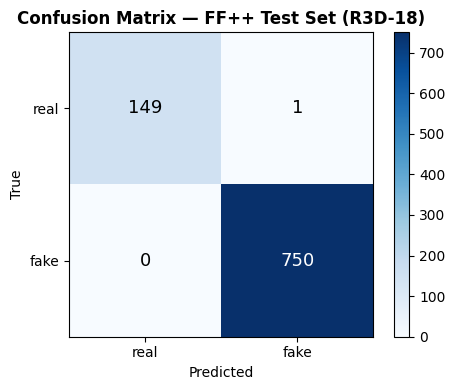

In [ ]:
print("Classification Report — FF++ Test Set (R3D-18):\n")
print(classification_report(r3d_ffpp_m["y_true"], r3d_ffpp_m["y_pred"],
                             target_names=["real", "fake"], zero_division=0))

cm = confusion_matrix(r3d_ffpp_m["y_true"], r3d_ffpp_m["y_pred"])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(["real", "fake"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["real", "fake"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=13)
ax.set_title("Confusion Matrix — FF++ Test Set (R3D-18)", fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "20_r3d18_ffpp_cm.png"), dpi=150, bbox_inches="tight")
plt.show()

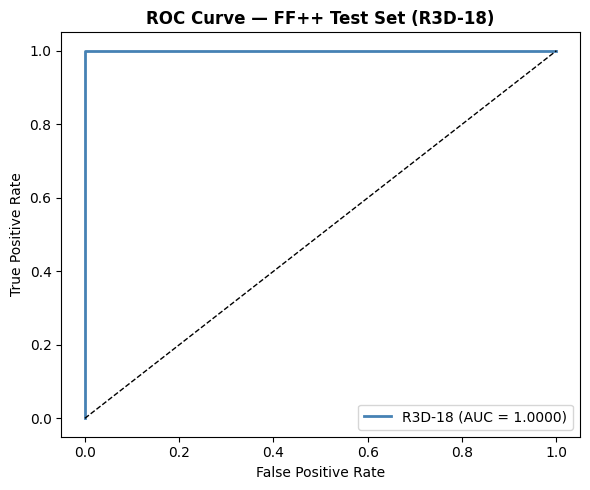

In [ ]:
fpr, tpr, _ = roc_curve(r3d_ffpp_m["y_true"], r3d_ffpp_m["y_prob"])

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2,
        label=f"R3D-18 (AUC = {r3d_ffpp_m['auc']:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("ROC Curve — FF++ Test Set (R3D-18)", fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "20b_r3d18_ffpp_roc.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
celebdf_loader_fast = DataLoader(celebdf_dataset, batch_size=32,
                                  shuffle=False, num_workers=NUM_WORKERS,
                                  pin_memory=True)

print("Evaluating R3D-18 on Celeb-DF v2 (zero-shot)...")
r3d_celebdf_m = evaluate(r3d, celebdf_loader_fast, criterion, device)

print(f"\nCeleb-DF v2 Results:")
print(f"  Loss      : {r3d_celebdf_m['loss']:.4f}")
print(f"  Accuracy  : {r3d_celebdf_m['acc']:.4f}")
print(f"  Precision : {r3d_celebdf_m['precision']:.4f}")
print(f"  Recall    : {r3d_celebdf_m['recall']:.4f}")
print(f"  F1-Score  : {r3d_celebdf_m['f1']:.4f}")
print(f"  AUC       : {r3d_celebdf_m['auc']:.4f}")

save_results(r3d_celebdf_m, MODEL_DIR / "r3d18_celebdf_results.json")
print("\nCeleb-DF v2 results saved to Drive.")

Evaluating R3D-18 on Celeb-DF v2 (zero-shot)...

Celeb-DF v2 Results:
  Loss      : 1.1999
  Accuracy  : 0.6346
  Precision : 0.9419
  Recall    : 0.6148
  F1-Score  : 0.7440
  AUC       : 0.7556

Celeb-DF v2 results saved to Drive.


Classification Report — Celeb-DF v2 (R3D-18):

              precision    recall  f1-score   support

        real       0.24      0.76      0.36       890
        fake       0.94      0.61      0.74      5639

    accuracy                           0.63      6529
   macro avg       0.59      0.69      0.55      6529
weighted avg       0.85      0.63      0.69      6529



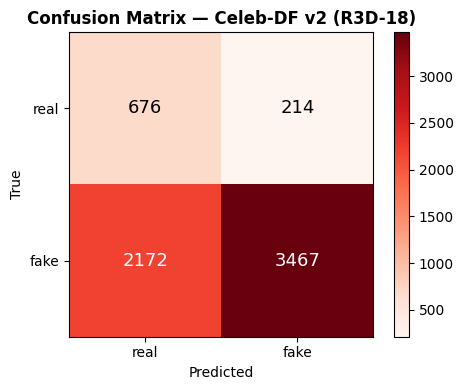

In [ ]:
print("Classification Report — Celeb-DF v2 (R3D-18):\n")
print(classification_report(r3d_celebdf_m["y_true"], r3d_celebdf_m["y_pred"],
                             target_names=["real", "fake"], zero_division=0))

cm = confusion_matrix(r3d_celebdf_m["y_true"], r3d_celebdf_m["y_pred"])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation="nearest", cmap="Reds")
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(["real", "fake"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["real", "fake"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=13)
ax.set_title("Confusion Matrix — Celeb-DF v2 (R3D-18)", fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "21_r3d18_celebdf_cm.png"), dpi=150, bbox_inches="tight")
plt.show()

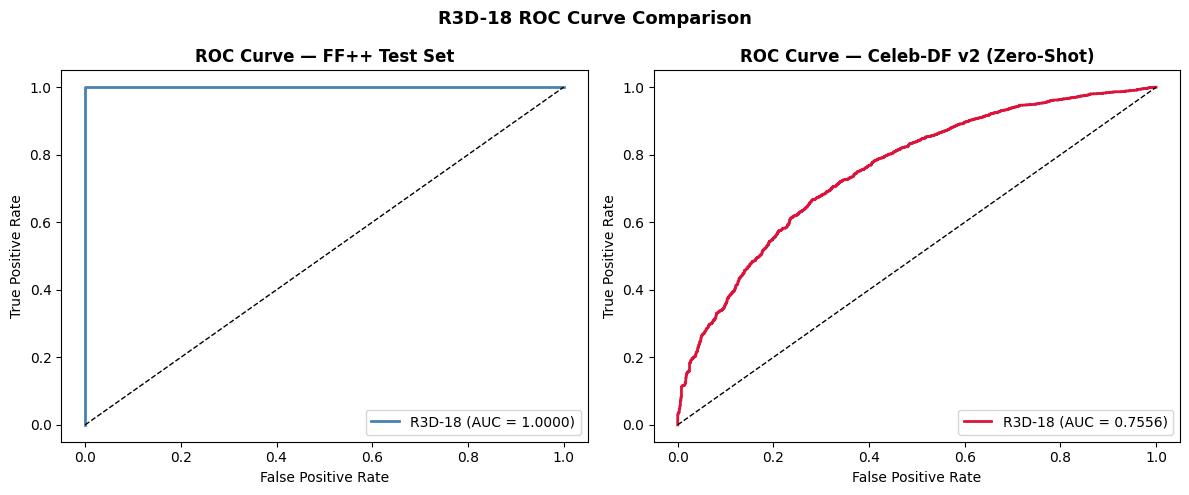

Generalization Gap (Δgen AUC) : 0.2444
  FF++ AUC     : 1.0000
  Celeb-DF AUC : 0.7556


In [ ]:
fpr_ff, tpr_ff, _ = roc_curve(r3d_ffpp_m["y_true"], r3d_ffpp_m["y_prob"])
fpr_cd, tpr_cd, _ = roc_curve(r3d_celebdf_m["y_true"], r3d_celebdf_m["y_prob"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr_ff, tpr_ff, color="steelblue", lw=2,
             label=f"R3D-18 (AUC = {r3d_ffpp_m['auc']:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("ROC Curve — FF++ Test Set", fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

axes[1].plot(fpr_cd, tpr_cd, color="crimson", lw=2,
             label=f"R3D-18 (AUC = {r3d_celebdf_m['auc']:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_title("ROC Curve — Celeb-DF v2 (Zero-Shot)", fontweight="bold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.suptitle("R3D-18 ROC Curve Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(str(PLOTS_DIR / "22_r3d18_roc_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

gen_gap = r3d_ffpp_m["auc"] - r3d_celebdf_m["auc"]
print(f"Generalization Gap (Δgen AUC) : {gen_gap:.4f}")
print(f"  FF++ AUC     : {r3d_ffpp_m['auc']:.4f}")
print(f"  Celeb-DF AUC : {r3d_celebdf_m['auc']:.4f}")

In [ ]:
print("=" * 55)
print("R3D-18 — FINAL RESULTS SUMMARY")
print("=" * 55)
print(f"\n{'Metric':<20} {'FF++ Test':>12} {'Celeb-DF v2':>12} {'Gap':>10}")
print("-" * 55)
for m, ff, cd in [
    ("Accuracy",  r3d_ffpp_m["acc"],       r3d_celebdf_m["acc"]),
    ("Precision", r3d_ffpp_m["precision"], r3d_celebdf_m["precision"]),
    ("Recall",    r3d_ffpp_m["recall"],    r3d_celebdf_m["recall"]),
    ("F1-Score",  r3d_ffpp_m["f1"],        r3d_celebdf_m["f1"]),
    ("AUC",       r3d_ffpp_m["auc"],       r3d_celebdf_m["auc"]),
]:
    print(f"  {m:<18} {ff:>12.4f} {cd:>12.4f} {ff-cd:>+10.4f}")

gen_gap = r3d_ffpp_m["auc"] - r3d_celebdf_m["auc"]
print(f"\n  Generalization Gap (Δgen AUC) : {gen_gap:.4f}")
print("=" * 55)

R3D-18 — FINAL RESULTS SUMMARY

Metric                  FF++ Test  Celeb-DF v2        Gap
-------------------------------------------------------
  Accuracy                 0.9989       0.6346    +0.3643
  Precision                0.9987       0.9419    +0.0568
  Recall                   1.0000       0.6148    +0.3852
  F1-Score                 0.9993       0.7440    +0.2553
  AUC                      1.0000       0.7556    +0.2444

  Generalization Gap (Δgen AUC) : 0.2444
